# 第64篇 | 方向导数与梯度向量：函数变化最快的方向

> **摘要**：方向导数是梯度向量的直观延伸——它回答「沿着某个方向走，函数变化有多快？」。梯度向量 ∇f 指向函数增长最快的方向，负梯度指向下降最快的方向，这正是梯度下降算法的全部几何原理。本篇从方向导数的计算出发，严格推导梯度向量的定义，并用代码可视化「最陡坡」和「最缓坡」。

嗨，我是小荷～ 上两篇我们讲了导数（一个变量）和偏导数（多个变量但一次只看一个）。今天要往前再走一步：如果我想沿着**任意方向**走，函数的变化率是多少？哪个方向变化最快？哪个方向变化最慢？这个问题的答案，就是梯度向量。理解了它，梯度下降对你来说就再也没有神秘感了。

---

## 一、方向导数：沿着任意方向的变化率

### 打个比方

想象一下，你现在正站在一座陡峭的山坡上（这就好比一个二元函数 z = f(x, y)，你的 GPS 坐标是 (x, y)，高度是 z）。


这时候，如果你想移动，你的选择是无穷无尽的：
- 偏导数 ∂f/ ∂x：代表你硬着头皮只往正东方向走，看海拔是涨是跌。偏
- 导数 ∂f/ ∂y：代表你死心眼只往正北方向走。
- 方向导数：你是个自由人。你问：“我如果现在朝着东北 45° 方向迈出一步，我的海拔会发生多大的变化？” 或者是“朝南偏西 30° 呢？”

通俗定义：你在某一个具体的点，朝着任意指定的方向 v 迈出一步时，函数值（海拔）的瞬时变化率，就叫做在这个点沿着该方向的方向导数。

你一定想问：“在这么多个方向里，哪一个方向的方向导数最大（爬坡最快）？”

数学家通过向量内积公式发现，当你面朝某一个特定方向时，方向导数能达到全场最大值。这个最陡峭、最直上的神圣方向，在数学上就被命名为——梯度 (▽f )。而这个方向导数的最大值，恰好就是梯度的模长（向量长度）。
- 梯度：一个带有指南针的向量，永远死死指向上坡最快的方向。
- 方向导数：是一个标量（数字）。是你任意挑一个方向后，山坡反馈给你的实际陡峭数字。

### 数学定义

函数 f(x, y) 在点 (x₀, y₀) 沿单位向量 **u** = (u₁, u₂) 的方向导数定义为：

$$D_{\mathbf{u}}f(x_0, y_0) = \lim_{h \to 0} \frac{f(x_0 + h u_1, y_0 + h u_2) - f(x_0, y_0)}{h}$$

几何直觉：在 (x₀, y₀) 处用垂直于 xy-平面的平面，沿着 u 方向「切」曲面，得到的截线的斜率就是方向导数。

代码演示

下面我们通过数值逼近的方法，计算并验证多元微积分中的方向导数（Directional Derivative）。
1. `numerical_directional_derivative ` 通过设置一个极小的步长(h = 10 ^ -7) ，利用有限差分法模拟了这一极限过程，从而计算出函数在指定方向上的瞬时变化率。
2. 测试方向与物理意义：代码在点 (1.0,1.0) 处选取了四个具有代表性的方向进行测试，揭示方向导数的几何与物理意义：
   - 坐标轴方向：沿 x 轴正向 (1,0) 和 y 轴正向 (0,1) 的方向导数，本质上就是该点处的偏导数 ∂f/∂x 和 ∂f/∂y。
   - 任意方向：沿对角（1/√2,1/√2）线的方向导数，展示了函数在斜向空间中的变化趋势。
   - 反向变化：沿负 (−1,0) 的方向导数，验证了方向导数的符号特性。若结果为正，说明沿该方向函数值增加；若为负，则说明函数值减少。

In [21]:
# 方向导数的数值计算与验证
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei','DejaVu Sans'] 
plt.rcParams['axes.unicode_minus'] = False
# 数学符号专用字体（内置，自带∇、积分、导数等全部数学符号）
plt.rcParams['mathtext.fontset'] = 'dejavusans'

# 定义测试函数：f(x,y) = x² + 2y² - 2xy + x - 2y
def f(x, y):
    """
    二元二次函数
    这个函数的梯度在低维空间中有着非常规则的几何形状
    """
    return x**2 + 2*y**2 - 2*x*y + x - 2*y

def numerical_directional_derivative(f, x0, y0, u, h=1e-7):
    """
    用定义计算方向导数 D_u f(x0, y0)
    
    参数:
        f: 二元函数
        x0, y0: 计算点
        u: 单位方向向量 (u1, u2)
        h: 增量（建议 1e-7 左右）
    返回:
        D_u f(x0, y0) 的数值近似
    """
    u1, u2 = u
    return (f(x0 + h*u1, y0 + h*u2) - f(x0, y0)) / h

# 在 (1, 1) 处测试几个方向的方向导数
x0, y0 = 1.0, 1.0

# 几个测试方向（必须为单位向量！）
test_directions = [
    ("x轴正向 (1,0)", (1.0, 0.0)),
    ("y轴正向 (0,1)", (0.0, 1.0)),
    ("对角线 (1/√2, 1/√2)", (1/np.sqrt(2), 1/np.sqrt(2))),
    ("负x轴 (-1,0)", (-1.0, 0.0)),
]

print("=== 方向导数数值验证 ===")
print(f"计算点: ({x0}, {y0})")
print(f"f(x,y) = x² + 2y² - 2xy + x - 2y\n")

for name, u in test_directions:
    D_u = numerical_directional_derivative(f, x0, y0, u)
    print(f"方向: {name}")
    print(f"  D_u f = {D_u:.6f}")
    if D_u > 0:
        print(f"  → 沿此方向，f 在增加")
    elif D_u < 0:
        print(f"  → 沿此方向，f 在减少")
    else:
        print(f"  → 沿此方向，f 的变化率为 0（可能是极值点）")
    print()

=== 方向导数数值验证 ===
计算点: (1.0, 1.0)
f(x,y) = x² + 2y² - 2xy + x - 2y

方向: x轴正向 (1,0)
  D_u f = 1.000000
  → 沿此方向，f 在增加

方向: y轴正向 (0,1)
  D_u f = 0.000000
  → 沿此方向，f 在增加

方向: 对角线 (1/√2, 1/√2)
  D_u f = 0.707107
  → 沿此方向，f 在增加

方向: 负x轴 (-1,0)
  D_u f = -1.000000
  → 沿此方向，f 在减少



**关键观察**：方向导数可正可负，可大可小。这引出了下一个核心问题：**哪个方向的方向导数最大？**

---

## 二、梯度向量：方向导数的最大值方向

**梯度的定义**

函数 f(x, y) 在点 (x, y) 的**梯度向量**（gradient vector）定义为：

$$\nabla f(x, y) = \left( \frac{\partial f}{\partial x}, \frac{\partial f}{\partial y} \right)$$

对于 n 元函数：∇f = (∂f/∂x₁, ∂f/∂x₂, ..., ∂f/∂x_n)

**梯度与方向导数的关系（核心定理）**

**定理**：设 u 是单位向量，则方向导数

$$D_{\mathbf{u}}f = \nabla f \cdot \mathbf{u} = \|\nabla f\| \cdot \|\mathbf{u}\| \cdot \cos \theta = \|\nabla f\| \cdot \cos \theta$$

其中 θ 是梯度向量 ∇f 与方向 u 的夹角。

**推论**（这是整篇最重要的结论）：
1. 当 **u** 与 ∇f **同向**时（θ=0°，cosθ=1），方向导数**最大**，等于 ||∇f||
2. 当 **u** 与 ∇f **反向**时（θ=180°，cosθ=-1），方向导数**最小**，等于 -||∇f||
3. 当 **u** 与 ∇f **垂直**时（θ=90°，cosθ=0），方向导数 = 0（「等高线」方向）

**代码演示**

下面我们通过向量运算，验证多元微积分中梯度（Gradient）与方向导数（Directional Derivative）之间最核心的数学定理。
1. 核心公式：方向导数 = 梯度 · 方向向量
   - 代码通过 `np.dot(grad, u)` 验证了方向导数的本质公式：$D_{\mathbf{u}}f = \nabla f \cdot \mathbf{u} = ||\nabla f|| \cdot ||\mathbf{u}|| \cdot \cos(\theta)$。由于 $\mathbf{u}$ 是单位向量，方向导数的大小完全取决于梯度向量与方向向量之间的夹角 $\theta$。
2. 梯度方向的三大几何性质
   -   **最速上升方向（沿梯度）**：当方向向量 $\mathbf{u}$ 与梯度 $\nabla f$ 同向时（$\theta = 0^\circ$），点积取得最大值，即 $D_{\mathbf{u}}f = ||\nabla f||$。这证明了梯度方向是函数值增长最快的方向。
   - **最速下降方向（沿负梯度）**：当方向向量 $\mathbf{u}$ 与梯度反向时（$\theta = 180^\circ$），点积取得最小值，即 $D_{\mathbf{u}}f = -||\nabla f||$。这正是机器学习**梯度下降算法**的数学灵魂——模型参数必须沿着负梯度方向更新，才能以最陡峭、最快速的步伐逼近损失函数的极小值。
   - **零变化方向（垂直梯度）**：当方向向量 $\mathbf{u}$ 与梯度正交（$\theta = 90^\circ$）时，点积为 0。在几何上，这意味着沿着这个方向移动，函数值 $f(x,y)$ 保持不变。这正是等高线（Contour Line）的切线方向，它完美解释了为什么梯度总是垂直于等高线。


In [15]:
import numpy as np

def grad_f(x, y):
    """
    f(x,y) = x² + 2y² - 2xy + x - 2y 的梯度函数
    梯度由两个一阶偏导数组成：
    ∂f/∂x = 2x - 2y + 1  对x的偏导
    ∂f/∂y = 4y - 2x - 2  对y的偏导
    返回数组 [∂f/∂x, ∂f/∂y] 梯度向量
    """
    # 计算x方向偏导数
    df_dx = 2*x - 2*y + 1
    # 计算y方向偏导数
    df_dy = 4*y - 2*x - 2
    # 组装梯度向量并返回
    return np.array([df_dx, df_dy])

# 选定验证点坐标 (1.0, 1.0)
x0, y0 = 1.0, 1.0
# 代入函数，计算该点的梯度向量
grad = grad_f(x0, y0)
# np.linalg.norm 计算梯度向量的模（长度）||∇f||
grad_norm = np.linalg.norm(grad)

# 打印标题
print("=== 梯度向量与方向导数的关系 ===")
# 输出计算坐标点
print(f"计算点: ({x0}, {y0})")
# 输出完整梯度向量
print(f"梯度向量 ∇f = {grad}")
# 输出梯度向量长度
print(f"梯度的模 ||∇f|| = {grad_norm:.6f}\n")

# -------------------------- 验证1：沿梯度正方向，方向导数最大 --------------------------
# 梯度向量 / 梯度模长 = 梯度方向的单位向量（长度归一化为1）
u_grad = grad / grad_norm
# 方向导数公式：D_u f = ∇f · u （梯度向量和单位方向向量做点积）
D_along_grad = np.dot(grad, u_grad)
print(f"沿梯度方向 u = {u_grad}:")
# 打印方向导数结果，等于梯度模长，证明此时变化率最大
print(f"  D_u f = {D_along_grad:.6f} = ||∇f|| = {grad_norm:.6f} ✓")
print(f"  → 方向导数最大！\n")

# -------------------------- 验证2：沿负梯度方向，方向导数最小 --------------------------
# 负梯度归一化，得到负梯度方向单位向量
u_neg_grad = -grad / grad_norm
# 计算该方向的方向导数
D_against_grad = np.dot(grad, u_neg_grad)
print(f"沿负梯度方向 u = {u_neg_grad}:")
# 结果等于负的梯度模长，变化率最小（下降最快）
print(f"  D_u f = {D_against_grad:.6f} = -||∇f|| = {-grad_norm:.6f} ✓")
print(f"  → 方向导数最小！\n")

# -------------------------- 验证3：垂直梯度方向，方向导数为0 --------------------------
# 数学规律：向量(a,b)垂直向量为 (-b,a)，保证点积为0
u_perp = np.array([-grad[1], grad[0]]) / grad_norm
# 垂直方向计算方向导数
D_perp = np.dot(grad, u_perp)
print(f"沿垂直梯度方向 u = {u_perp}:")
# 输出近似0，沿该方向函数值不变，对应等高线切线方向
print(f"  D_u f = {D_perp:.6f} ≈ 0 ✓")
print(f"  → 方向导数为 0，这是「等高线」方向")

=== 梯度向量与方向导数的关系 ===
计算点: (1.0, 1.0)
梯度向量 ∇f = [1. 0.]
梯度的模 ||∇f|| = 1.000000

沿梯度方向 u = [1. 0.]:
  D_u f = 1.000000 = ||∇f|| = 1.000000 ✓
  → 方向导数最大！

沿负梯度方向 u = [-1. -0.]:
  D_u f = -1.000000 = -||∇f|| = -1.000000 ✓
  → 方向导数最小！

沿垂直梯度方向 u = [-0.  1.]:
  D_u f = 0.000000 ≈ 0 ✓
  → 方向导数为 0，这是「等高线」方向


这段代码将前面学习的偏导数、方向导数和梯度下降算法彻底串联了起来：
-   **偏导数**构成了梯度向量的各个分量。
-   **梯度向量**指明了空间中函数变化最剧烈的方向。
-   **方向导数**量化了我们在任意选定方向上利用梯度的程度。

这段代码用向量点积的几何意义，证明了梯度是函数变化的“最强信号”。它不仅解释了等高线的几何形态，更为神经网络中“为什么沿着负梯度方向更新参数”提供了最底层的数学合法性。

---

## 三、梯度的几何直觉：最陡的爬坡方向

下面我们对二元曲面 f(x,y) 同时提供两种可视化，直观展示梯度的几何含义：
- 左图 3D 曲面：立体直观看到红色梯度箭头往山坡上坡方向；
   - `quiver`函数：批量一次性画成千上万个矢量场，适合梯度热力场
- 右图 2D 等高线：俯视视角，清晰看出梯度箭头与等高线互相垂直。
   - `contour`函数：绘制二维等高线图
   - `skip = 3`：原始网格是 50×50=2500 个点，如果全部画箭头会密密麻麻重叠看不清；
隔 3 个点采样，大幅减少箭头数量，画面干净。

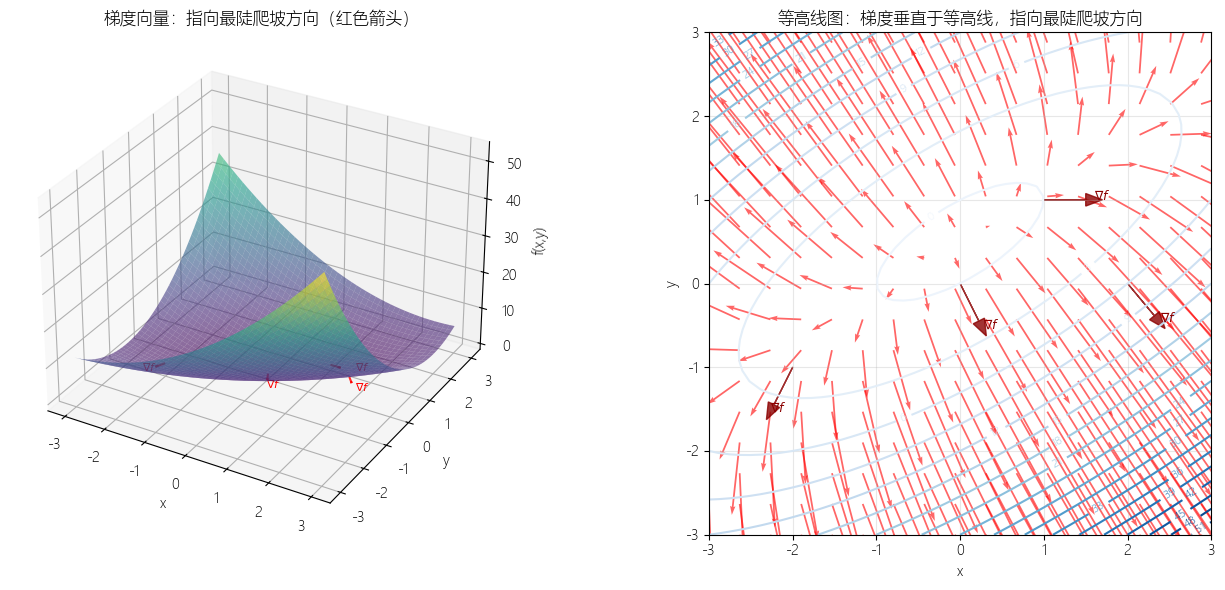

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 定义二元目标函数 f(x,y) = x² + 2y² - 2xy + x - 2y
def f(x, y):
    return x**2 + 2*y**2 - 2*x*y + x - 2*y

# 定义梯度函数，返回(∂f/∂x, ∂f/∂y)向量
def grad_f(x, y):
    # 对x的一阶偏导
    df_dx = 2*x - 2*y + 1
    # 对y的一阶偏导
    df_dy = 4*y - 2*x - 2
    # 组装梯度向量数组返回
    return np.array([df_dx, df_dy])

# 生成x、y轴均匀采样区间，用于构建平面网格
x_range = np.linspace(-3, 3, 50)
y_range = np.linspace(-3, 3, 50)
# 生成网格矩阵X、Y，覆盖平面上所有坐标点
X, Y = np.meshgrid(x_range, y_range)
# 计算网格上每个坐标对应的函数高度Z，构成3D曲面
Z = f(X, Y)

# 批量计算整个网格所有点的两个偏导数，得到完整梯度场
grad_x = 2*X - 2*Y + 1
grad_y = 4*Y - 2*X - 2

# 创建画布，一行两列子图，总尺寸宽14高6英寸
fig = plt.figure(figsize=(14, 6))

# ===================== 左子图：3D曲面 + 梯度箭头投影 =====================
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# 绘制半透明3D曲面，viridis配色，开启抗锯齿优化显示
surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6, antialiased=True)

# 选定4个采样点，在曲面标注梯度红色箭头
seed_points = [(-2, -1), (0, 0), (1, 1), (2, 0)]
# 遍历每个标注点
for x0, y0 in seed_points:
    # 计算当前点梯度向量
    grad = grad_f(x0, y0)
    # 计算梯度向量模长，用于归一化箭头长度
    grad_norm = np.linalg.norm(grad)
    
    # quiver：3D空间绘制箭头
    # 参数含义：起点x,y,z；箭头x偏移、y偏移、z偏移；控制箭头长度、颜色、透明度、箭头比例
    ax1.quiver(x0, y0, f(x0, y0), grad[0]/grad_norm*0.5, grad[1]/grad_norm*0.5, 
                0, length=0.5, color='red', alpha=0.8, arrow_length_ratio=0.3)
    
    # 在箭头末端添加文字标注 ∇f
    ax1.text(x0 + grad[0]/grad_norm*0.6, y0 + grad[1]/grad_norm*0.6, 
             f(x0, y0) + 0.2, r'$\nabla f$', fontsize=8, color='red')

# 设置左图标题与坐标轴标签
ax1.set_title('梯度向量：指向最陡爬坡方向（红色箭头）')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('f(x,y)')

# ===================== 右子图：2D等高线图 + 梯度矢量场 =====================
ax2 = fig.add_subplot(1, 2, 2)
# 绘制20层等高线，蓝色系半透明
contour = ax2.contour(X, Y, Z, levels=20, cmap='Blues', alpha=1)
# 在等高线上标注每层对应的函数数值
ax2.clabel(contour, inline=True, fontsize=8)

# skip=3，网格隔3个点画一个梯度箭头，避免箭头过密重叠
skip = 3
# quiver绘制平面矢量梯度场：起点网格坐标、箭头xy偏移、颜色缩放
# 每一组 (X,Y,grad_x,grad_y) 对应一支箭头：
# 从 (X,Y) 出发，指向 (X+grad_x, Y+grad_y)。
ax2.quiver(X[::skip, ::skip], Y[::skip, ::skip], 
            grad_x[::skip, ::skip], grad_y[::skip, ::skip], 
            color='red', alpha=0.6, scale=30)

# 遍历4个关键点，单独绘制加粗深色梯度箭头
for x0, y0 in seed_points:
    grad = grad_f(x0, y0)
    grad_norm = np.linalg.norm(grad)
    # arrow绘制平面箭头：起点xy、xy偏移、箭头头部宽/长、填充与边框颜色
    ax2.arrow(x0, y0, grad[0]/grad_norm*0.5, grad[1]/grad_norm*0.5, 
              head_width=0.15, head_length=0.2, fc='darkred', ec='darkred', alpha=0.8)
    # 箭头末端标注梯度符号
    ax2.text(x0 + grad[0]/grad_norm*0.6, y0 + grad[1]/grad_norm*0.6, 
             r'$\nabla f$', fontsize=9, color='darkred')

# 右图配置
ax2.set_title('等高线图：梯度垂直于等高线，指向最陡爬坡方向')
ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal') # 横纵坐标轴等比例，防止图形拉伸变形

# 自动调整子图间距，避免文字重叠遮挡
plt.tight_layout()
# 弹出窗口展示绘图结果
plt.show()

观察要点：
1. 梯度向量 ∇f 垂直于等高线（方向导数最大的方向）：在任意一点上，梯度向量总是与该点的等高线严格垂直。因为沿着等高线移动时函数值不变（方向导数为0），所以垂直于等高线的方向必然是函数值发生变化的方向。
2. 梯度指向函数增长最快的方向（最陡爬坡）所有的梯度箭头都指向曲面隆起的方向，即函数值 f(x,y) 增长最快的方向。梯度向量的长度（模长∣∣∇f∣∣ ）代表了该点处坡度的陡峭程度。向量越长，说明地形越陡，函数值变化越剧烈。
3. 负梯度 -∇f 指向函数下降最快的方向（最陡下坡）


---

## 四、梯度下降算法：负梯度的力量

**算法原理**

梯度下降的更新公式：

$$\mathbf{w}_{t+1} = \mathbf{w}_t - \eta \cdot \nabla L(\mathbf{w}_t)$$

其中 η（学习率）控制每一步走多大。

**为什么往负梯度方向走？** 因为负梯度方向是函数**下降最快**的方向！

**代码演示**

下面我们以二元凸二次损失函数为例，从零完整手写批量梯度下降，把所有前置数学知识（偏导、梯度、方向导数、等高线等）再串联一次。
1. `loss`：自定义损失，本损失是开口向上的抛物面，仅有全局最小值，无论起点在哪，梯度下降一定收敛到 (3,-1)，无局部极小干扰。
2. `gradient`：手动推导梯度
3. `gradient_descent`：封装迭代逻辑（含早停）。
   - 计算梯度：通过 gradient 函数获取当前位置的偏导数向量，指明“最陡下坡”的方向。
   - 步长控制：将梯度乘以学习率（learning_rate），决定每一步迈出的距离。
   - 参数更新：在当前参数 w 的基础上减去更新量，向损失函数的谷底移动。
   - “早停机制”（Early Stopping）：`if np.linalg.norm(grad) < 1e-6: break`，当梯度的模长（范数）趋近于 0 时，说明我们已经到达了函数的极小值点（谷底），此时再往前走已经没有意义。
5. 可视化等高线收敛轨迹 + 损失下降曲线

=== 梯度下降算法演示 ===
初始点: (-5.0, 4.0)
学习率 η = 0.1
最终点: (2.999886, -1.000000)
真实最小值点: (3, -1)
最终损失: 0.0000000130



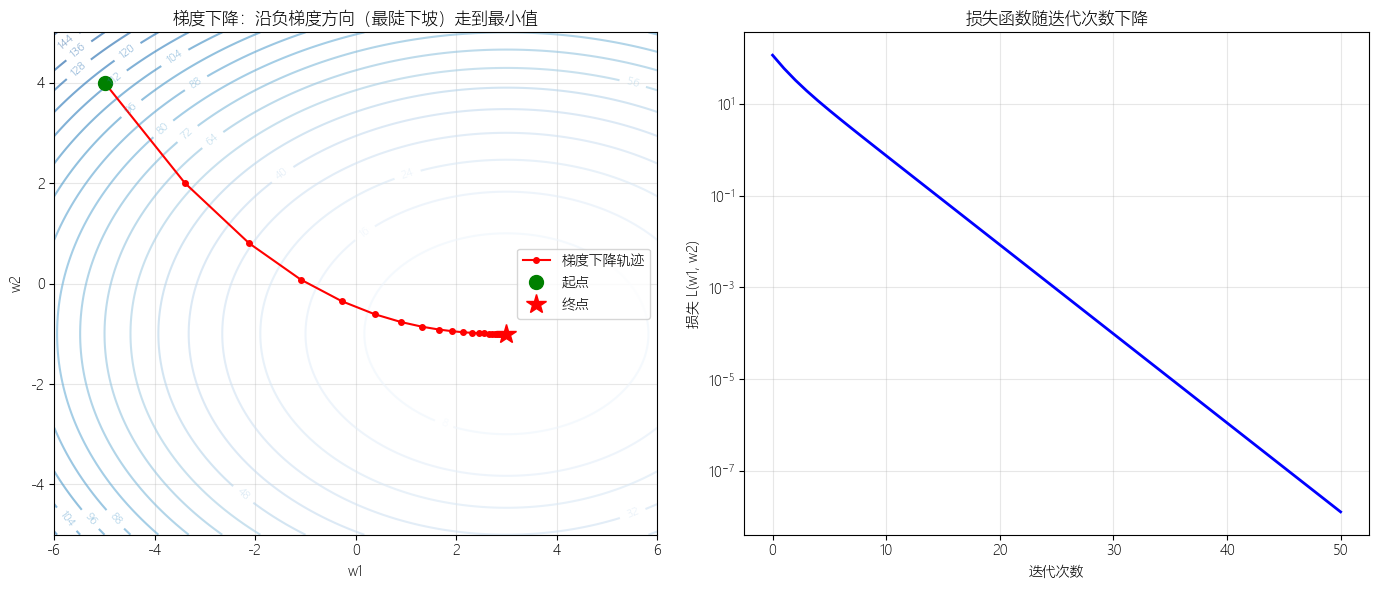

观察要点：
1. 梯度下降沿着负梯度方向（最陡下坡）走到最小值
2. 学习率 η 控制每一步走多大
3. 损失函数单调下降（如果学习率不太大）


In [29]:
# 梯度下降的完整实现：从零开始
import numpy as np
import matplotlib.pyplot as plt

# 定义损失函数（二元二次函数，有唯一最小值）
def loss(w1, w2):
    """
    L(w1, w2) = (w1-3)² + 2(w2+1)²
    最小值在 (w1*, w2*) = (3, -1) 处
    凸函数，全局只有一个极小值，适合演示梯度下降
    """
    return (w1 - 3)**2 + 2*(w2 + 1)**2

def gradient(w1, w2):
    """
    梯度向量 ∇L = (∂L/∂w1, ∂L/∂w2)
    对w1求偏导：∂L/∂w1 = 2(w1-3)
    对w2求偏导：∂L/∂w2 = 4(w2+1)
    返回由两个偏导数组成的梯度向量
    """
    dl_dw1 = 2 * (w1 - 3)
    dl_dw2 = 4 * (w2 + 1)
    return np.array([dl_dw1, dl_dw2])

# 梯度下降算法主体封装函数
def gradient_descent(start_point, learning_rate, n_iterations):
    """
    梯度下降算法实现
    
    参数:
        start_point: 初始参数点 (w1, w2)
        learning_rate: 学习率 η，控制每一步更新幅度
        n_iterations: 最大迭代次数上限
    返回:
        trajectory: 每一轮参数(w1,w2)的更新轨迹数组
        losses: 每一轮对应的损失值数组
    """
    # 将起点转为浮点numpy数组，方便向量运算
    w = np.array(start_point, dtype=float)
    # 记录轨迹，先存入初始点
    trajectory = [w.copy()]
    # 记录损失，先存入初始点的损失
    losses = [loss(w[0], w[1])]
    
    # 循环迭代更新参数
    for i in range(n_iterations):
        # 计算当前参数位置的梯度
        grad = gradient(w[0], w[1])
        
        # 梯度下降核心更新公式：w := w - η·∇L
        # 减去梯度，向损失下降最快的方向移动
        w = w - learning_rate * grad
        
        # 保存更新后的参数到轨迹列表
        trajectory.append(w.copy())
        # 保存当前参数对应的损失值
        losses.append(loss(w[0], w[1]))
        
        # 早停机制：梯度向量模长极小，说明已经逼近极小值，提前终止循环
        if np.linalg.norm(grad) < 1e-6:
            print(f"  早停：第 {i+1} 步梯度范数 < 1e-6")
            break
    
    # 转为numpy数组方便后续绘图切片
    return np.array(trajectory), np.array(losses)

# ---------------------- 超参数初始化，执行梯度下降 ----------------------
# 设定远离最优解的起点，方便观察收敛过程
start = (-5.0, 4.0)
learning_rate = 0.1    # 学习率
n_iterations = 50      # 最大迭代步数

# 运行梯度下降，拿到参数轨迹与损失序列
trajectory, losses = gradient_descent(start, learning_rate, n_iterations)

# 控制台打印结果对比
print("=== 梯度下降算法演示 ===")
print(f"初始点: {start}")
print(f"学习率 η = {learning_rate}")
print(f"最终点: ({trajectory[-1, 0]:.6f}, {trajectory[-1, 1]:.6f})")
print(f"真实最小值点: (3, -1)")
print(f"最终损失: {losses[-1]:.10f}\n")

# ---------------------- 绘图可视化 ----------------------
# 创建一行两列画布，宽14高6英寸
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左图：等高线图 + 参数迭代轨迹
# 生成w1、w2轴均匀采样点
w1_range = np.linspace(-6, 6, 100)
w2_range = np.linspace(-5, 5, 100)
# 构建二维网格
W1, W2 = np.meshgrid(w1_range, w2_range)
# 计算网格所有点的损失值，用于绘制等高线
L = loss(W1, W2)

# 绘制20层蓝色半透明等高线
contour = axes[0].contour(W1, W2, L, levels=20, cmap='Blues', alpha=0.6)
# 在等高线上标注损失数值
axes[0].clabel(contour, inline=True, fontsize=8)

# 绘制迭代全过程轨迹：红色圆点连线
axes[0].plot(trajectory[:, 0], trajectory[:, 1], 'ro-', markersize=4, 
              linewidth=1.5, label='梯度下降轨迹')
# 绿色圆圈标记迭代起点
axes[0].plot(trajectory[0, 0], trajectory[0, 1], 'go', markersize=10, 
              label='起点')
# 红色五角星标记迭代终点
axes[0].plot(trajectory[-1, 0], trajectory[-1, 1], 'r*', markersize=15, 
              label='终点')

# 左图配置
axes[0].set_title('梯度下降：沿负梯度方向（最陡下坡）走到最小值')
axes[0].set_xlabel('w1'); axes[0].set_ylabel('w2')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal') # 横纵轴等比例，不拉伸图形

# 右图：损失随迭代次数下降曲线
axes[1].plot(losses, 'b-', linewidth=2)
axes[1].set_title('损失函数随迭代次数下降')
axes[1].set_xlabel('迭代次数'); axes[1].set_ylabel('损失 L(w1, w2)')
axes[1].grid(True, alpha=0.3)
# Y轴取对数刻度，放大观察后期微小损失变化
axes[1].set_yscale('log')

# 自动调整子图间距，避免文字重叠
plt.tight_layout()
# 展示图像
plt.show()


**可视化解读**
- 左图（参数空间）：在等高线地图上，红色的轨迹展示了参数从初始点 (−5,4) 出发，沿着垂直于等高线的方向（最陡下坡），一步步逼近真实最小值点 (3,−1) 的完整路径。
- 右图（损失空间）：展示了损失值随迭代次数的下降曲线。值得注意的是，代码使用了对数坐标（Log Scale）。在对数坐标下，如果曲线呈现近似直线，说明损失值正在呈指数级下降，这是模型健康、高效收敛的典型标志。

**超参数影响拓展**
- 学习率过小：收敛极慢，需要更多迭代；
- 学习率过大：震荡发散，损失不降反升；
- 迭代次数不足：无法充分逼近最优值；
- 开启早停：梯度趋近 0 时提前结束，减少冗余计算。

---

## 📝 本篇小结

| 概念 | 公式 | 直觉 |
|------|------|------|
| **方向导数** | D_u f = ∇f·u | 沿方向 u 的变化率 |
| **梯度向量** | ∇f = (∂f/∂x₁, ..., ∂f/∂x_n) | 指向最陡爬坡方向 |
| **最大方向导数** | max_u D_u f = ||∇f|| | 沿梯度方向 |
| **最小方向导数** | min_u D_u f = -||∇f|| | 沿负梯度方向 |
| **梯度下降** | w := w - η·∇f | 沿负梯度方向走到最小值 |

## 🏋️ 课后挑战

1. 对于函数 f(x,y) = sin(x)·cos(y)，手工计算 ∇f，然后用代码数值验证你的结果。
2. 修改梯度下降代码，尝试不同的学习率（η = 0.01, 0.1, 0.5, 1.0），观察收敛速度和稳定性。学习率太大会发生什么？

> 下期预告：链式法则与计算图 —— 反向传播的数学基础。